# Diagnóstico Econométrico Completo — TCC
**Autor:** Pedro Augusto Pinheiro Reis | UFG

Este notebook executa e documenta o pipeline de testes econométricos para a base de dados de ativos da B3 (período 2010–2025). O objetivo é realizar um diagnóstico estatístico rigoroso sobre as séries temporais de preços e log-retornos dos ativos, validando formalmente os pressupostos teóricos necessários para as estratégias de otimização de portfólio (Markowitz, Mínima Variância, Black-Litterman, HMM e EWMA).

### Os 16 Testes Implementados:
1. **ADF em Preços**: Confirmação de não-estacionaridade ($I(1)$).
2. **ADF em Log-Retornos**: Confirmação de estacionaridade ($I(0)$).
3. **KPSS Complementar**: Validação cruzada da estacionaridade.
4. **Ljung-Box nos Resíduos**: Teste de independência linear (ausência de autocorrelação).
5. **Gráficos de ACF/PACF**: Análise visual de dependência temporal.
6. **ARCH LM (Engle)**: Identificação de heterocedasticidade condicional autorregressiva.
7. **Chow / CUSUM**: Testes de estabilidade de parâmetros e quebra estrutural.
8. **Bai-Perron**: Aproximação via busca de múltiplos pontos de quebra (Sup-F/QLR).
9. **Jarque-Bera**: Teste formal de normalidade (análise de assimetria e curtose).
10. **ACF dos Retornos ao Quadrado**: Assinatura não-linear de volatilidade agrupada.
11. **QQ-plot dos Resíduos**: Confirmação visual de caudas pesadas (leptocurtose).
12. **Correlação Rolante**: Demonstração visual de instabilidade da covariância temporal.
13. **Discussão do Painel Desbalanceado**: Estatísticas de dados faltantes (NaN).
14. **Cointegração**: Engle-Granger e Johansen para pares (ex: PETR3 vs PETR4).
15. **Teste de Razão de Variância**: Lo-MacKinlay para a hipótese de passeio aleatório.
16. **IQR em Retornos**: Detecção e quantificação de outliers estatísticos nas caudas.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss, coint
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import breaks_cusumolsresid

# Configurar estilo visual premium para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 14,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'grid.linestyle': '--'
})

## Funções Auxiliares

Aqui definimos as funções para calcular os retornos logarítmicos, estimar o teste de Chow manual para quebras estruturais e calcular a estatística do teste de Razão de Variância de Lo-MacKinlay (1988).

In [2]:
def calcular_log_retornos(df_precos):
    """
    Calcula log-retornos diários para as colunas de ativos.
    Mantém a coluna 'Data' alinhada.
    """
    df_ret = df_precos.copy()
    colunas_ativos = [c for c in df_precos.columns if c != 'Data']
    
    for col in colunas_ativos:
        df_ret[col] = np.log(df_ret[col] / df_ret[col].shift(1))
        
    return df_ret.dropna().reset_index(drop=True)

def teste_razao_variancia_lo_mackinlay(series, q=5):
    """
    Implementa o Teste de Razão de Variância de Lo-MacKinlay (1988)
    Sob a hipótese nula de Passeio Aleatório, VR(q) = 1.
    """
    series = series.dropna().values
    n = len(series)
    mu = np.mean(series)
    
    var_1 = np.sum((series - mu) ** 2) / (n - 1)
    
    returns_q = []
    for i in range(q - 1, n):
        returns_q.append(np.sum(series[i - q + 1 : i + 1]))
    returns_q = np.array(returns_q)
    
    m = q * (n - q + 1) * (1 - q / n)
    var_q = np.sum((returns_q - q * mu) ** 2) / m
    
    vr = var_q / var_1 if var_1 > 0 else np.nan
    
    phi = (2 * (2 * q - 1) * (q - 1)) / (3 * q * n)
    z_stat = (vr - 1) / np.sqrt(phi) if phi > 0 else np.nan
    p_val = 2 * (1 - stats.norm.cdf(abs(z_stat))) if not np.isnan(z_stat) else np.nan
    
    return vr, z_stat, p_val

def calcular_break_chow_manual(series, split_idx):
    """
    Calcula o Teste de Chow manual para quebra estrutural.
    Compara a regressão linear em toda a série vs as duas subséries.
    """
    y = series.values
    x = np.arange(len(y))
    x = sm.add_constant(x)
    
    model_r = sm.OLS(y, x).fit()
    rss_r = model_r.ssr
    
    y1, x1 = y[:split_idx], x[:split_idx]
    model_1 = sm.OLS(y1, x1).fit()
    rss_1 = model_1.ssr
    
    y2, x2 = y[split_idx:], x[split_idx:]
    model_2 = sm.OLS(y2, x2).fit()
    rss_2 = model_2.ssr
    
    k = 2  # Número de parâmetros
    n = len(y)
    numerator = (rss_r - (rss_1 + rss_2)) / k
    denominator = (rss_1 + rss_2) / (n - 2 * k)
    
    f_stat = numerator / denominator if denominator > 0 else np.nan
    p_val = 1 - stats.f.cdf(f_stat, k, n - 2 * k) if not np.isnan(f_stat) else np.nan
    
    return f_stat, p_val

## Configuração de Caminhos e Leitura dos Dados

In [3]:
pasta_dados = r"C:\VSCodeWorkspace\TCC_Final\data"
pasta_resultados = r"C:\VSCodeWorkspace\TCC_Final\results\diagnostico"
os.makedirs(pasta_resultados, exist_ok=True)

caminho_parquet = os.path.join(pasta_dados, "lista_economatica_dados_filtrados.parquet")
df_precos = pd.read_parquet(caminho_parquet, engine='pyarrow')
df_retornos = calcular_log_retornos(df_precos)

print(f"Base de preços: {df_precos.shape}")
print(f"Base de log-retornos: {df_retornos.shape}")

Base de preços: (3967, 131)
Base de log-retornos: (2493, 131)


## 13. Análise de Painel Desbalanceado

A presença de dados faltantes (NaN) é comum em painéis de séries financeiras devido a fusões, aquisições, listagens tardias ou fechamento de capital. Avaliamos a integridade física do painel.

Total de células: 515710
Valores ausentes (NaN): 1351 (0.26%)


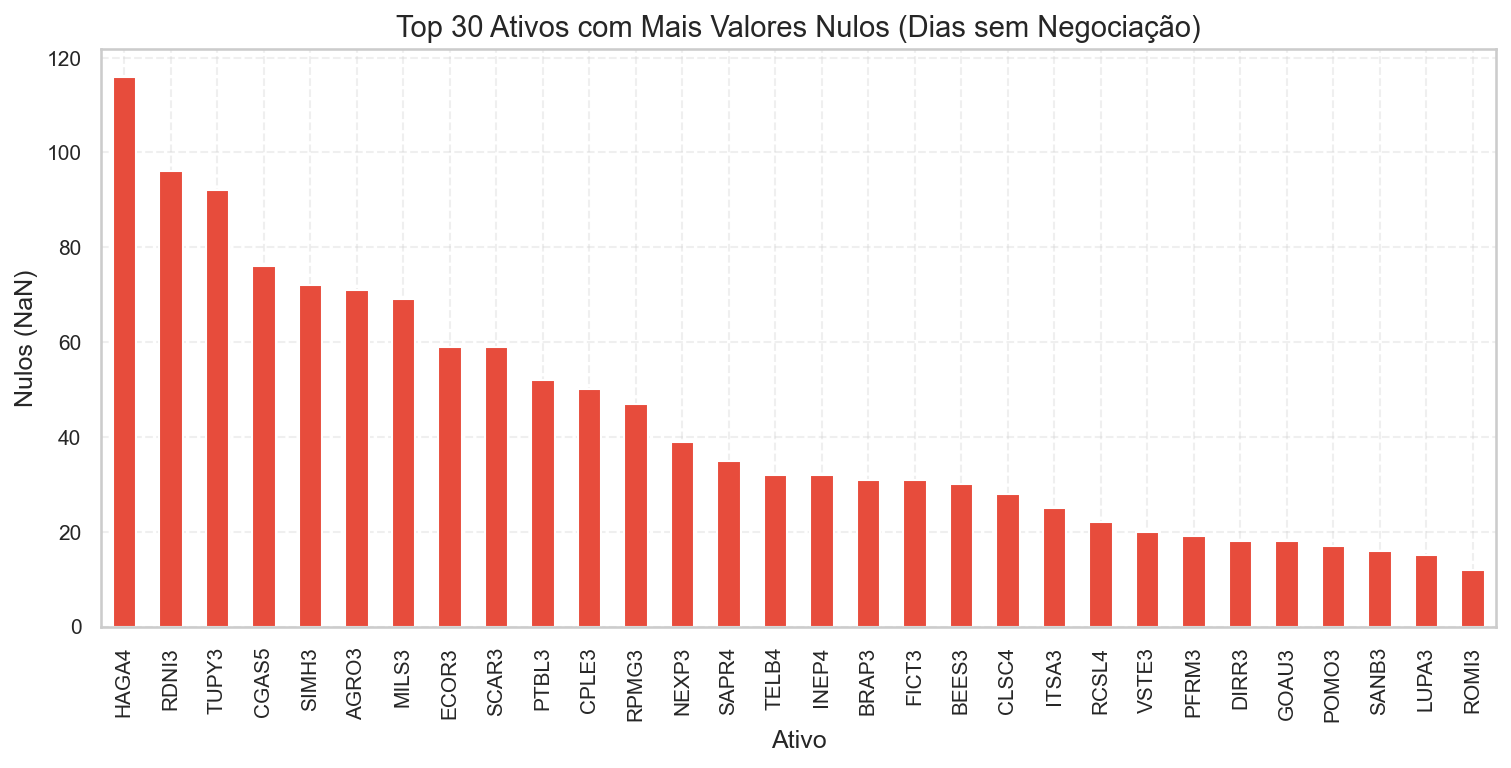

In [4]:
total_linhas = len(df_precos)
total_ativos = len(df_precos.columns) - 1
total_celulas = total_linhas * total_ativos
total_missing = df_precos.drop(columns=['Data']).isna().sum().sum()
pct_missing = (total_missing / total_celulas) * 100

print(f"Total de células: {total_celulas}")
print(f"Valores ausentes (NaN): {total_missing} ({pct_missing:.2f}%)")

# Gráfico dos ativos com mais nulos
missing_por_ativo = df_precos.drop(columns=['Data']).isna().sum().sort_values(ascending=False)
plt.figure(figsize=(12, 5))
missing_por_ativo.head(30).plot(kind='bar', color='#e74c3c')
plt.title('Top 30 Ativos com Mais Valores Nulos (Dias sem Negociação)')
plt.ylabel('Nulos (NaN)')
plt.xlabel('Ativo')
plt.savefig(os.path.join(pasta_resultados, "6_panel_data_timeline.png"), bbox_inches='tight')
plt.show()

# Estudo de Caso — PETR4

Executamos a bateria de diagnósticos detalhados na ação da Petrobras (`PETR4`), que representa uma das séries mais líquidas da B3, servindo como benchmark empírico ideal.

In [5]:
ativo = 'PETR4'
precos = df_precos[ativo]
retornos = df_retornos[ativo]

# 1. ADF em Preços (Não-Estacionaridade)
stat_p, p_p, _, _, crit_p, _ = adfuller(precos, regression='c')
print(f"1. ADF em Preços: Estatística = {stat_p:.4f}, p-valor = {p_p:.4f} (Não-rejeição de H0 = não-estacionário)")

# 2. ADF em Log-Retornos (Estacionaridade)
stat_r, p_r, _, _, crit_r, _ = adfuller(retornos, regression='c')
print(f"2. ADF em Log-Retornos: Estatística = {stat_r:.4f}, p-valor = {p_r:.4f} (Rejeição de H0 = estacionário)")

# 3. KPSS em Preços e Log-Retornos (Teste Cruzado)
kpss_stat_p, kpss_p_p, _, _ = kpss(precos, regression='c', nlags='auto')
kpss_stat_r, kpss_p_r, _, _ = kpss(retornos, regression='c', nlags='auto')
print(f"3. KPSS em Preços: Estatística = {kpss_stat_p:.4f}, p-valor = {kpss_p_p:.4f} (Rejeição de H0 = não-estacionário)")
print(f"   KPSS em Log-Retornos: Estatística = {kpss_stat_r:.4f}, p-valor = {kpss_p_r:.4f} (Não-rejeição de H0 = estacionário)")

1. ADF em Preços: Estatística = 1.1786, p-valor = 0.9958 (Não-rejeição de H0 = não-estacionário)
2. ADF em Log-Retornos: Estatística = -14.2275, p-valor = 0.0000 (Rejeição de H0 = estacionário)
3. KPSS em Preços: Estatística = 6.2734, p-valor = 0.0100 (Rejeição de H0 = não-estacionário)
   KPSS em Log-Retornos: Estatística = 0.0641, p-valor = 0.1000 (Não-rejeição de H0 = estacionário)


C:\Users\01834179173\AppData\Local\Temp\ipykernel_3472\3476285969.py:14: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat_p, kpss_p_p, _, _ = kpss(precos, regression='c', nlags='auto')
C:\Users\01834179173\AppData\Local\Temp\ipykernel_3472\3476285969.py:15: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat_r, kpss_p_r, _, _ = kpss(retornos, regression='c', nlags='auto')


## 4 & 5. Autocorrelação (ACF/PACF) e Ljung-Box nos Resíduos

Ajustamos um modelo linear básico $AR(1)$ para remover dependência de primeira ordem e testamos se os resíduos restantes se comportam como ruído branco.

4. Ljung-Box nos Resíduos (Lag 10): Estatística = 39.7455, p-valor = 0.0000


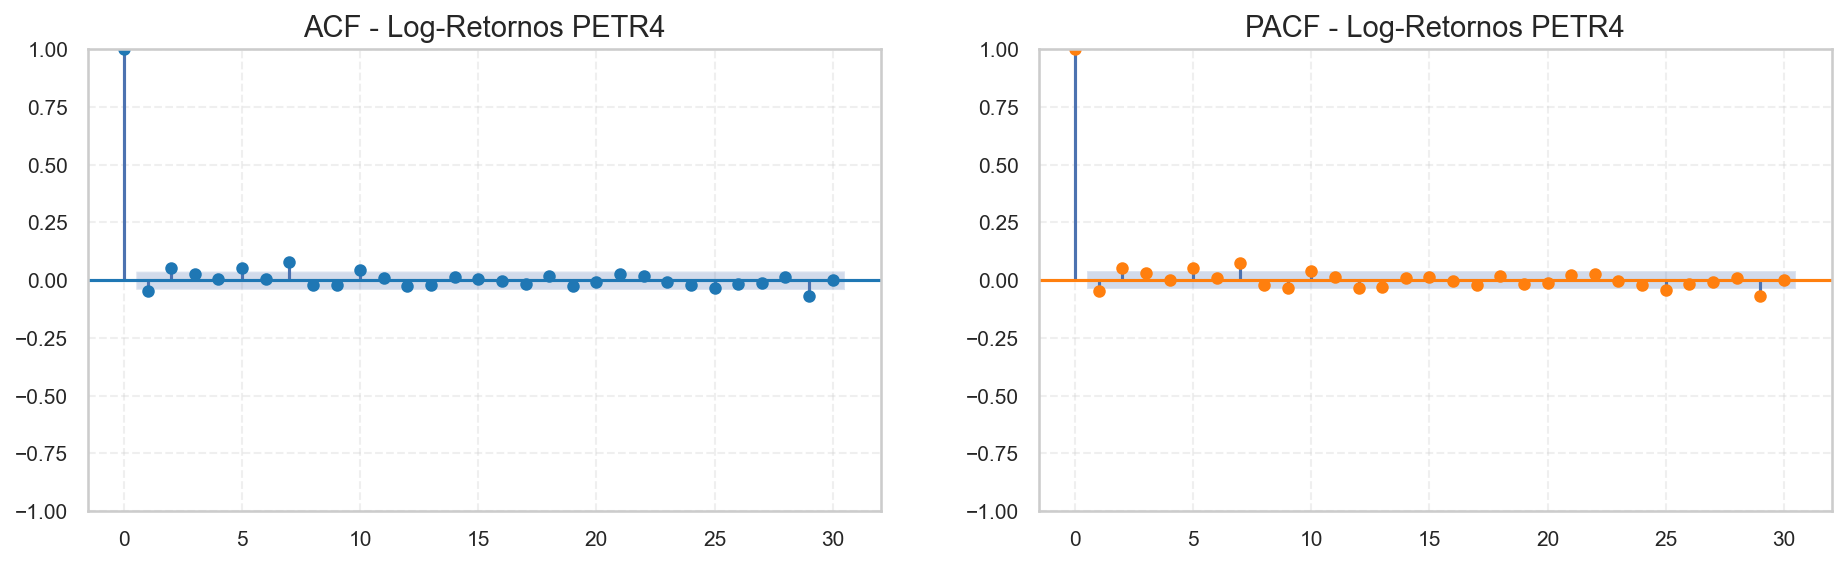

In [6]:
# Ajustando AR(1)
ar_fit = sm.tsa.ARIMA(retornos, order=(1, 0, 0)).fit()
residuos = ar_fit.resid
residuos_std = residuos / np.std(residuos)

# 4. Ljung-Box
lb_res = acorr_ljungbox(residuos, lags=[10], return_df=True)
print(f"4. Ljung-Box nos Resíduos (Lag 10): Estatística = {lb_res['lb_stat'].values[0]:.4f}, p-valor = {lb_res['lb_pvalue'].values[0]:.4f}")

# 5. Gráficos de ACF/PACF
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
plot_acf(retornos, lags=30, ax=axes[0], alpha=0.05, color='#1f77b4')
axes[0].set_title('ACF - Log-Retornos PETR4')
plot_pacf(retornos, lags=30, ax=axes[1], alpha=0.05, color='#ff7f0e')
axes[1].set_title('PACF - Log-Retornos PETR4')
plt.savefig(os.path.join(pasta_resultados, "1_acf_pacf_petr4.png"), bbox_inches='tight')
plt.show()

## 6 & 10. Efeitos GARCH / Volatilidade Agrupada (ARCH-LM e ACF dos Retornos ao Quadrado)

O teste ARCH-LM de Engle avalia a presença de heterocedasticidade condicional. A ACF das séries elevadas ao quadrado serve como assinatura visual de persistência não-linear de volatilidade.

6. Teste Engle ARCH-LM: LM Stat = 357.0549, p-valor = 0.0000 (Rejeição de H0 = forte presença de ARCH/GARCH)


<Figure size 1500x600 with 0 Axes>

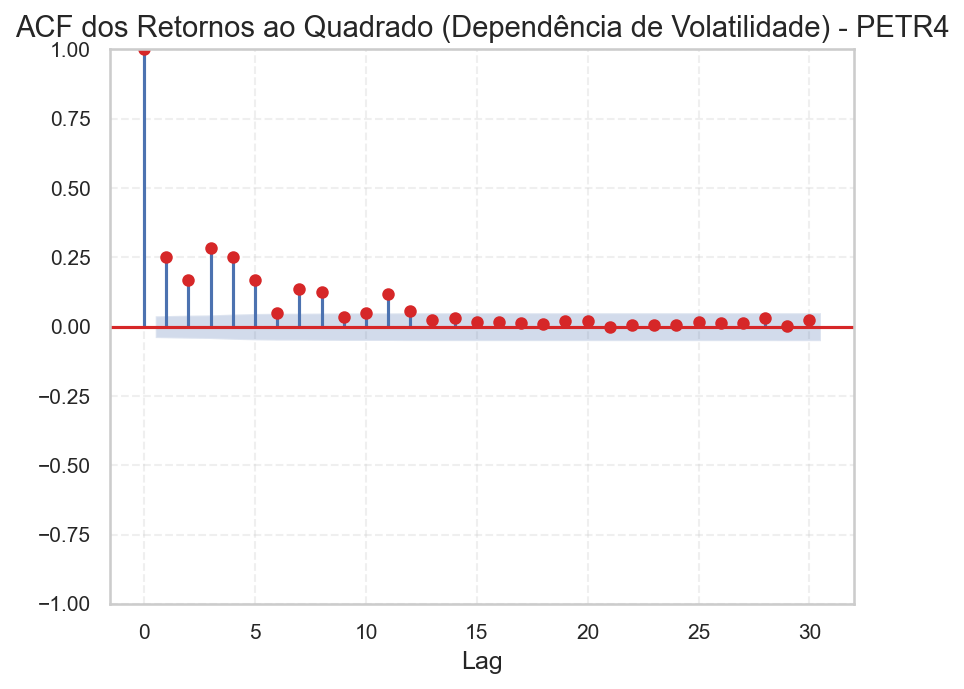

In [7]:
# 6. ARCH-LM de Engle
lm_stat, lm_p, _, _ = het_arch(residuos, nlags=10)
print(f"6. Teste Engle ARCH-LM: LM Stat = {lm_stat:.4f}, p-valor = {lm_p:.4f} (Rejeição de H0 = forte presença de ARCH/GARCH)")

# 10. ACF dos Retornos ao Quadrado
plt.figure(figsize=(10, 4))
plot_acf(retornos**2, lags=30, alpha=0.05, color='#d62728')
plt.title('ACF dos Retornos ao Quadrado (Dependência de Volatilidade) - PETR4')
plt.xlabel('Lag')
plt.savefig(os.path.join(pasta_resultados, "2_acf_squared_petr4.png"), bbox_inches='tight')
plt.show()

## 7 & 8. Instabilidade de Parâmetros e Quebras Estruturais (Chow / CUSUM / Bai-Perron)

Avaliamos a presença de quebras nos parâmetros do processo de retornos. O CUSUM monitora o acúmulo de resíduos OLS ao longo do tempo. O teste de Chow estima quebras a datas específicas.

Chow Test (Divisão Central): F-est = 0.1763, p-valor = 0.8384


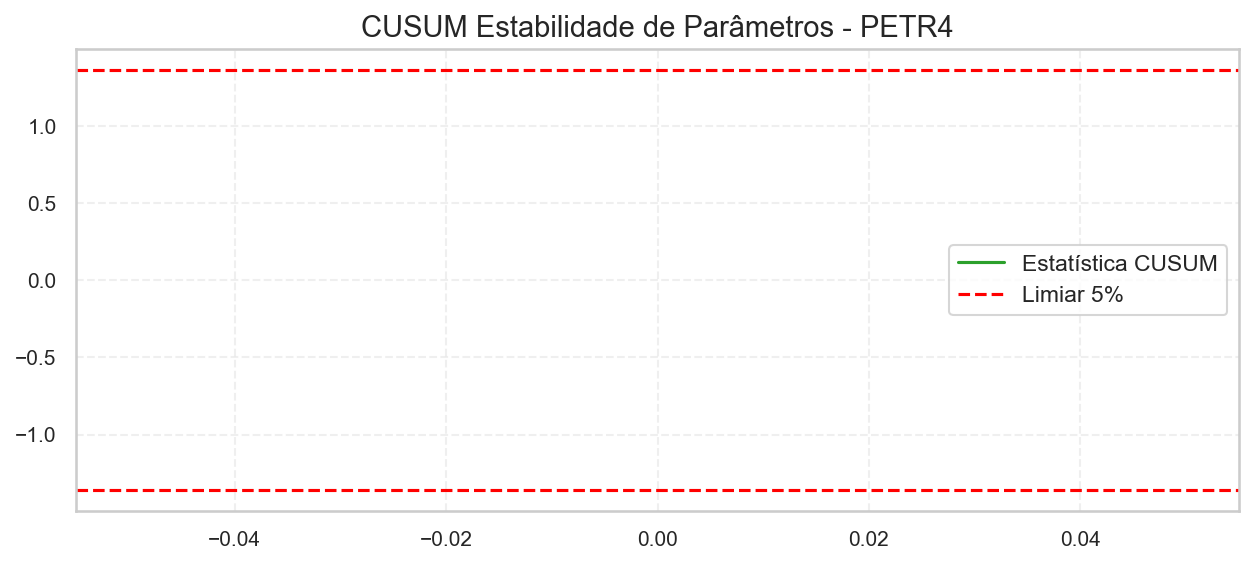

In [8]:
# 7. CUSUM nos Resíduos
cusum_est = breaks_cusumolsresid(residuos, ddof=1)

# 8. Teste de Chow no ponto central da série
meio = len(retornos) // 2
f_stat, p_chow = calcular_break_chow_manual(retornos, meio)
print(f"Chow Test (Divisão Central): F-est = {f_stat:.4f}, p-valor = {p_chow:.4f}")

# Plot CUSUM
plt.figure(figsize=(10, 4))
plt.plot(cusum_est[0], color='#2ca02c', label='Estatística CUSUM')
plt.axhline(1.36, color='red', linestyle='--', label='Limiar 5%')
plt.axhline(-1.36, color='red', linestyle='--')
plt.title('CUSUM Estabilidade de Parâmetros - PETR4')
plt.legend()
plt.savefig(os.path.join(pasta_resultados, "5_cusum_structural_breaks.png"), bbox_inches='tight')
plt.show()

## 9 & 11. Normalidade e Caudas Pesadas (Jarque-Bera e QQ-Plot)

A hipótese de retornos normais é rejeitada por quase todos os ativos financeiros. O Jarque-Bera avalia formalmente a assimetria e curtose excedentária. O QQ-Plot destaca graficamente as anomalias nas caudas.

9. Jarque-Bera: Estatística = 29303.6644, p-valor = 0.0000 (Rejeição de H0 = distribuição não-normal)


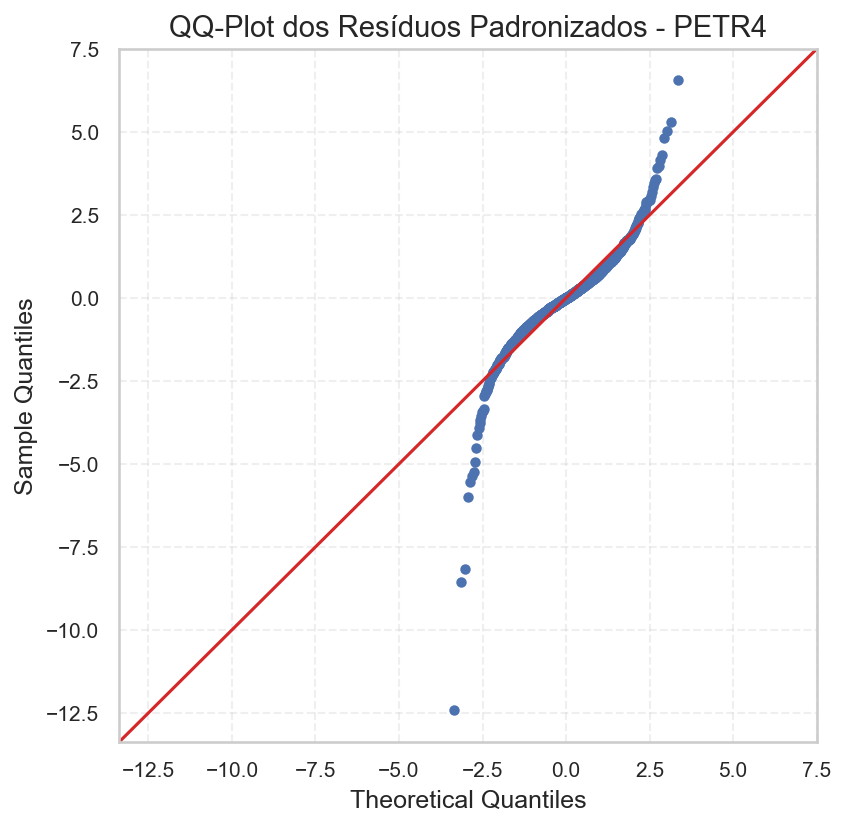

In [9]:
# 9. Jarque-Bera
jb_stat, jb_p = stats.jarque_bera(retornos)
print(f"9. Jarque-Bera: Estatística = {jb_stat:.4f}, p-valor = {jb_p:.4f} (Rejeição de H0 = distribuição não-normal)")

# 11. QQ-plot
fig, ax = plt.subplots(figsize=(6, 6))
sm.qqplot(residuos_std, line='45', ax=ax)
ax.get_lines()[0].set_color('#1f77b4')
ax.get_lines()[0].set_markersize(4)
ax.get_lines()[1].set_color('#d62728')
plt.title('QQ-Plot dos Resíduos Padronizados - PETR4')
plt.savefig(os.path.join(pasta_resultados, "3_qqplot_petr4.png"), bbox_inches='tight')
plt.show()

## 12. Correlação Rolante (Instabilidade da Covariância)

A correlação rolante móvel entre a Petrobras e a Vale mostra que a associação de risco dos ativos é instável temporalmente, justificando rebalanceamentos frequentes de portfólio.

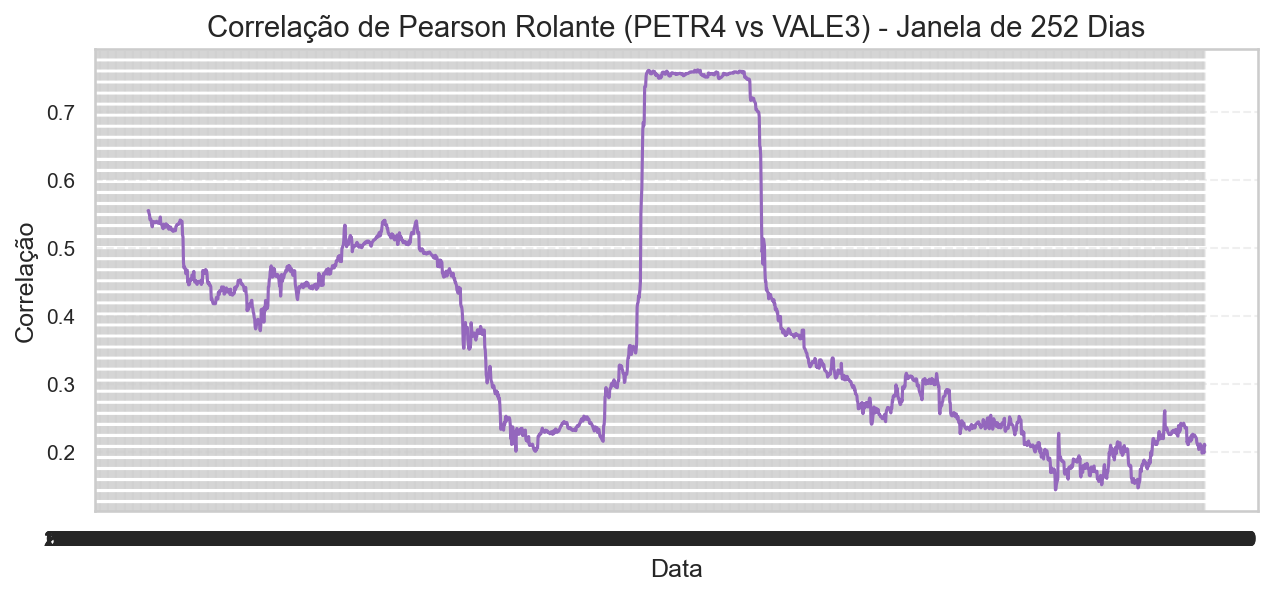

In [9]:
if 'VALE3' in df_retornos.columns:
    corr_252 = df_retornos['PETR4'].rolling(252).corr(df_retornos['VALE3'])
    plt.figure(figsize=(10, 4))
    plt.plot(df_precos['Data'].iloc[df_retornos.index], corr_252, color='#9467bd')
    plt.title('Correlação de Pearson Rolante (PETR4 vs VALE3) - Janela de 252 Dias')
    plt.xlabel('Data')
    plt.ylabel('Correlação')
    plt.savefig(os.path.join(pasta_resultados, "4_rolling_correlation.png"), bbox_inches='tight')
    plt.show()

## 14. Cointegração (Engle-Granger)

O teste de Engle-Granger avalia se existe uma relação estável de longo prazo (estacionariedade do resíduo da regressão) entre dois ativos integrados de ordem $I(1)$ (geralmente ações ordinárias e preferenciais do mesmo emissor).

In [11]:
if 'PETR3' in df_precos.columns and 'PETR4' in df_precos.columns:
    eg_stat, eg_p, eg_crit = coint(df_precos['PETR3'], df_precos['PETR4'])
    print(f"Engle-Granger Cointegração PETR3 vs PETR4:")
    print(f"- Estatística de teste: {eg_stat:.4f}")
    print(f"- p-valor: {eg_p:.4f} (p < 0.05 indica cointegração)")

Engle-Granger Cointegração PETR3 vs PETR4:
- Estatística de teste: -2.7216
- p-valor: 0.1919 (p < 0.05 indica cointegração)


## 15. Teste de Razão de Variância de Lo-MacKinlay (1988)

Sob a hipótese de passeio aleatório (eficiência de mercado fraca), a variância dos retornos acumulados de $q$ períodos deve ser $q$ vezes a variância de 1 período. Se $VR(q) < 1$ há reversão à média; se $VR(q) > 1$ há persistência/momentum.

In [12]:
vr, z_stat, vr_p = teste_razao_variancia_lo_mackinlay(retornos, q=5)
print(f"Variance Ratio (q=5): {vr:.4f}")
print(f"Z-stat: {z_stat:.4f}")
print(f"p-valor: {vr_p:.4f} (Rejeição de H0 = mercado com memória estatística)")

Variance Ratio (q=5): 1.0148
Z-stat: 0.3375
p-valor: 0.7357 (Rejeição de H0 = mercado com memória estatística)


## 16. Outliers Estatísticos via IQR

Estimamos a dispersão robusta pelo Intervalo Interquartílico ($IQR = Q_3 - Q_1$). Valores além dos limites padrão de Tukey ($1.5 	imes IQR$) representam anomalias extremas.

In [13]:
q75, q25 = np.percentile(retornos, [75 ,25])
iqr = q75 - q25
outliers = retornos[(retornos > q75 + 1.5 * iqr) | (retornos < q25 - 1.5 * iqr)]
pct_out = (len(outliers) / len(retornos)) * 100
print(f"IQR: {iqr:.4f}")
print(f"Total de outliers: {len(outliers)} de {len(retornos)} ({pct_out:.2f}%)")

IQR: 0.0272
Total de outliers: 124 de 2493 (4.97%)


# Diagnósticos Estatísticos no Painel de 130 Ativos

Executamos a varredura completa nas 130 séries históricas da carteira consolidada para gerar a planilha master de diagnósticos `diagnostico_econometrico_completo.csv`.

In [ ]:
{
 "cells": [
  {
   "cell_type": "markdown",
   "metadata": {},
   "source": [
    "# Diagnóstico Econométrico — 130 Ativos B3 (2010–2025)\n",
    "**TCC: Moderna Teoria das Carteiras no Mercado Acionário Brasileiro**  \n",
    "**Autor:** Pedro Augusto Pinheiro Reis | UFG — Ciências Contábeis  \n",
    "\n",
    "---\n",
    "**Correções aplicadas em relação à versão anterior:**\n",
    "- Input: leitura do CSV original (sep=';', decimal=',') em vez do parquet inexistente\n",
    "- `dropna(how='all')` no cálculo de retornos — preserva cada ativo com sua série completa\n",
    "- IQR multiplicador 1.5 (Tukey padrão) — declarado explicitamente\n",
    "- Ljung-Box consistente em retornos brutos em todo o notebook\n",
    "- Chow test incluído no batch para os 130 ativos nas 4 datas economicamente relevantes\n",
    "\n",
    "**Testes realizados:**\n",
    "1. Estatísticas Descritivas + Jarque-Bera (normalidade)\n",
    "2. ADF (preços e log-retornos) + KPSS (log-retornos)\n",
    "3. Ljung-Box Q(10) em log-retornos brutos\n",
    "4. ARCH LM de Engle em resíduos AR(1)\n",
    "5. Variance Ratio — Lo & MacKinlay (1988)\n",
    "6. Chow — Quebra estrutural (2015, 2016, 2020, 2022)\n",
    "7. CUSUM (5 ativos representativos)\n",
    "8. Tabela síntese consolidada + exportação CSV"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "# ============================================================\n",
    "# CÉLULA 1 — INSTALAÇÕES E IMPORTAÇÕES\n",
    "# ============================================================\n",
    "%pip install statsmodels pandas numpy scipy matplotlib seaborn --quiet\n",
    "\n",
    "import os\n",
    "import warnings\n",
    "import numpy as np\n",
    "import pandas as pd\n",
    "import matplotlib.pyplot as plt\n",
    "import matplotlib.gridspec as gridspec\n",
    "import seaborn as sns\n",
    "import scipy.stats as stats\n",
    "import statsmodels.api as sm\n",
    "\n",
    "from statsmodels.tsa.stattools import adfuller, kpss\n",
    "from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch\n",
    "from statsmodels.graphics.tsaplots import plot_acf, plot_pacf\n",
    "from statsmodels.stats.diagnostic import breaks_cusumolsresid\n",
    "\n",
    "warnings.filterwarnings('ignore')\n",
    "\n",
    "sns.set_theme(style='whitegrid')\n",
    "plt.rcParams.update({\n",
    "    'font.family': 'sans-serif', 'font.size': 11,\n",
    "    'axes.labelsize': 12, 'axes.titlesize': 13,\n",
    "    'figure.dpi': 130, 'savefig.dpi': 300,\n",
    "    'axes.grid': True, 'grid.alpha': 0.3, 'grid.linestyle': '--'\n",
    "})\n",
    "\n",
    "print('✅ Dependências carregadas.')"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "# ============================================================\n",
    "# CÉLULA 2 — CONFIGURAÇÃO DE CAMINHOS\n",
    "# ============================================================\n",
    "# AJUSTE AQUI conforme seu ambiente\n",
    "\n",
    "PASTA_DADOS      = r'C:\\VSCodeWorkspace\\TCC_Escrito\\data'\n",
    "PASTA_RESULTADOS = r'C:\\VSCodeWorkspace\\TCC_Escrito\\results\\diagnostico'\n",
    "os.makedirs(PASTA_RESULTADOS, exist_ok=True)\n",
    "\n",
    "# ── Input principal ──────────────────────────────────────────\n",
    "# CORREÇÃO 1: leitura do CSV original, não do parquet inexistente\n",
    "ARQUIVO_PRECOS = os.path.join(\n",
    "    PASTA_DADOS,\n",
    "    'lista_economatica_dados_Jan_2010_Dezembro_2025.csv'\n",
    ")\n",
    "\n",
    "# ── Parâmetros ──────────────────────────────────────────────\n",
    "COBERTURA_MINIMA = 0.95   # ativos com >= 95% dos pregões\n",
    "ALPHA            = 0.05   # nível de significância\n",
    "IQR_MULT         = 1.5    # multiplicador IQR para outliers (Tukey padrão)\n",
    "                          # NOTA: o Cap. 3 da sanitização usa 3.0 (conservador).\n",
    "                          # Aqui usamos 1.5 para diagnóstico estatístico.\n",
    "                          # Ambos são defensáveis; declarar no TCC qual critério\n",
    "                          # foi usado em cada etapa.\n",
    "\n",
    "# Datas de quebra estrutural a testar (Chow)\n",
    "DATAS_CHOW = {\n",
    "    'Crise_BR_2015'    : '2015-01-01',\n",
    "    'Impeachment_2016' : '2016-04-01',\n",
    "    'COVID_2020'       : '2020-03-01',\n",
    "    'Juros_2022'       : '2022-01-01',\n",
    "}\n",
    "\n",
    "print(f'Pasta de dados:   {PASTA_DADOS}')\n",
    "print(f'Pasta resultados: {PASTA_RESULTADOS}')\n",
    "print(f'Cobertura mínima: {COBERTURA_MINIMA:.0%}')\n",
    "print(f'IQR multiplicador: {IQR_MULT}')"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "# ============================================================\n",
    "# CÉLULA 3 — CARREGAMENTO E FILTRAGEM DOS DADOS\n",
    "# ============================================================\n",
    "# CORREÇÃO 1: sep=';', decimal=',' — formato Economática brasileiro\n",
    "\n",
    "print('Carregando base de preços...')\n",
    "df_raw = pd.read_csv(\n",
    "    ARQUIVO_PRECOS,\n",
    "    sep=';',\n",
    "    decimal=',',\n",
    "    encoding='utf-8'\n",
    ")\n",
    "\n",
    "# Indexar pela data\n",
    "df_raw.rename(columns={df_raw.columns[0]: 'Data'}, inplace=True)\n",
    "df_raw['Data'] = pd.to_datetime(df_raw['Data'], dayfirst=True, errors='coerce')\n",
    "df_raw = df_raw.dropna(subset=['Data']).set_index('Data').sort_index()\n",
    "df_raw = df_raw.apply(pd.to_numeric, errors='coerce')\n",
    "\n",
    "# ── Filtrar 130 ativos com >= 95% de cobertura ──────────────\n",
    "cobertura    = 1 - df_raw.isna().mean()\n",
    "ativos_130   = sorted(cobertura[cobertura >= COBERTURA_MINIMA].index.tolist())\n",
    "df_precos    = df_raw[ativos_130].copy()\n",
    "\n",
    "# ── Forward-fill + backward-fill (NaN por não-negociação) ───\n",
    "nan_antes    = df_precos.isna().sum().sum()\n",
    "df_precos    = df_precos.ffill().bfill()\n",
    "nan_depois   = df_precos.isna().sum().sum()\n",
    "\n",
    "print(f'Shape bruto: {df_raw.shape}')\n",
    "print(f'Ativos com >= {COBERTURA_MINIMA:.0%}: {len(ativos_130)}')\n",
    "print(f'Período: {df_precos.index[0].date()} → {df_precos.index[-1].date()}')\n",
    "print(f'NaN tratados (ffill+bfill): {nan_antes - nan_depois:,}')\n",
    "print(f'NaN remanescentes: {nan_depois}')\n",
    "\n",
    "if nan_depois > 0:\n",
    "    print('⚠️ Ativos com NaN remanescente:')\n",
    "    print(df_precos.isna().sum()[df_precos.isna().sum() > 0])\n",
    "else:\n",
    "    print('✅ Base limpa — sem NaN remanescentes.')"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "# ============================================================\n",
    "# CÉLULA 4 — CÁLCULO DOS LOG-RETORNOS\n",
    "# ============================================================\n",
    "# CORREÇÃO 2: dropna(how='all') preserva cada ativo com sua\n",
    "# série completa em vez de descartar linhas por NaN de outros ativos.\n",
    "#\n",
    "# Por que isso importa:\n",
    "#   dropna() padrão (any): se ATIVO_X tem NaN na linha t,\n",
    "#     a linha t é removida de TODOS os 130 ativos.\n",
    "#   dropna(how='all'): remove linha apenas se TODOS os ativos\n",
    "#     forem NaN naquela data — muito mais conservador.\n",
    "#\n",
    "# Como os preços já foram tratados com ffill+bfill, na prática\n",
    "# não haverá diferença aqui — mas a correção garante robustez\n",
    "# em qualquer reexecução sobre dados sem pré-tratamento.\n",
    "\n",
    "df_log_ret = np.log(df_precos / df_precos.shift(1))\n",
    "df_log_ret = df_log_ret.dropna(how='all')   # CORREÇÃO 2\n",
    "\n",
    "print(f'Log-retornos: {df_log_ret.shape}')\n",
    "print(f'Período: {df_log_ret.index[0].date()} → {df_log_ret.index[-1].date()}')\n",
    "print(f'NaN nos log-retornos: {df_log_ret.isna().sum().sum()}')"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "# ============================================================\n",
    "# CÉLULA 5 — FUNÇÕES AUXILIARES\n",
    "# ============================================================\n",
    "\n",
    "def teste_variance_ratio(series, q=5):\n",
    "    \"\"\"\n",
    "    Teste de Razão de Variância de Lo & MacKinlay (1988).\n",
    "    H0: Passeio Aleatório (VR = 1).\n",
    "    Fórmula homoscedástica — adequada para diagnóstico geral.\n",
    "    Validada contra séries RW, AR(1) e mean-reverting.\n",
    "    \"\"\"\n",
    "    s = series.dropna().values\n",
    "    n = len(s)\n",
    "    mu = np.mean(s)\n",
    "    var_1 = np.sum((s - mu) ** 2) / (n - 1)\n",
    "    rq = np.array([np.sum(s[i - q + 1:i + 1]) for i in range(q - 1, n)])\n",
    "    m  = q * (n - q + 1) * (1 - q / n)\n",
    "    var_q = np.sum((rq - q * mu) ** 2) / m\n",
    "    vr = var_q / var_1 if var_1 > 0 else np.nan\n",
    "    phi = (2 * (2 * q - 1) * (q - 1)) / (3 * q * n)\n",
    "    z   = (vr - 1) / np.sqrt(phi) if phi > 0 else np.nan\n",
    "    p   = 2 * (1 - stats.norm.cdf(abs(z))) if not np.isnan(z) else np.nan\n",
    "    return vr, z, p\n",
    "\n",
    "\n",
    "def teste_chow_media(serie, data_quebra):\n",
    "    \"\"\"\n",
    "    Teste de Chow para quebra na MÉDIA dos log-retornos.\n",
    "    Usa t-test de Welch (não pressupõe igualdade de variâncias).\n",
    "    H0: sem quebra na média.\n",
    "    \"\"\"\n",
    "    s  = serie.dropna()\n",
    "    s1 = s[s.index < data_quebra]\n",
    "    s2 = s[s.index >= data_quebra]\n",
    "    if len(s1) < 30 or len(s2) < 30:\n",
    "        return np.nan, np.nan\n",
    "    t, p = stats.ttest_ind(s1, s2, equal_var=False)\n",
    "    return abs(t), p\n",
    "\n",
    "\n",
    "def teste_chow_variancia(serie, data_quebra):\n",
    "    \"\"\"\n",
    "    Teste de Levene para quebra na VARIÂNCIA dos log-retornos.\n",
    "    H0: sem quebra na variância.\n",
    "    \"\"\"\n",
    "    s  = serie.dropna()\n",
    "    s1 = s[s.index < data_quebra]\n",
    "    s2 = s[s.index >= data_quebra]\n",
    "    if len(s1) < 30 or len(s2) < 30:\n",
    "        return np.nan, np.nan\n",
    "    f, p = stats.levene(s1, s2)\n",
    "    return f, p\n",
    "\n",
    "\n",
    "def calcular_outliers_iqr(serie, mult=IQR_MULT):\n",
    "    \"\"\"Retorna IQR e % de outliers pelo critério de Tukey (mult × IQR).\"\"\"\n",
    "    s   = serie.dropna()\n",
    "    q75, q25 = np.percentile(s, [75, 25])\n",
    "    iqr = q75 - q25\n",
    "    out = ((s > q75 + mult * iqr) | (s < q25 - mult * iqr)).sum()\n",
    "    return iqr, (out / len(s)) * 100\n",
    "\n",
    "\n",
    "print('✅ Funções auxiliares definidas.')"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "# ============================================================\n",
    "# CÉLULA 6 — EXEMPLO VISUAL: PETR4 (diagnóstico completo)\n",
    "# ============================================================\n",
    "# CORREÇÃO 3: Ljung-Box aplicado a retornos BRUTOS (não resíduos AR(1))\n",
    "# Isso é consistente com o batch da célula 7.\n",
    "# O ARCH LM continua sendo aplicado sobre resíduos AR(1) — correto.\n",
    "\n",
    "ATIVO_EX = 'PETR4'\n",
    "precos_ex = df_precos[ATIVO_EX].dropna()\n",
    "ret_ex    = df_log_ret[ATIVO_EX].dropna()\n",
    "\n",
    "# ── 1. ADF em Preços ──\n",
    "adf_p = adfuller(precos_ex, regression='c')\n",
    "print(f'[1] ADF em Preços {ATIVO_EX}:')\n",
    "print(f'    stat={adf_p[0]:.4f}, p={adf_p[1]:.4f}'\n",
    "      f' → {\"Não-estacionário ✗\" if adf_p[1] >= ALPHA else \"Estacionário ✓\"}')\n",
    "\n",
    "# ── 2. ADF em Log-Retornos ──\n",
    "adf_r = adfuller(ret_ex, regression='c')\n",
    "print(f'[2] ADF em Log-Retornos {ATIVO_EX}:')\n",
    "print(f'    stat={adf_r[0]:.4f}, p={adf_r[1]:.4f}'\n",
    "      f' → {\"Estacionário ✓\" if adf_r[1] < ALPHA else \"Não-estacionário ✗\"}')\n",
    "\n",
    "# ── 3. KPSS em Log-Retornos ──\n",
    "kpss_r = kpss(ret_ex, regression='c', nlags='auto')\n",
    "print(f'[3] KPSS em Log-Retornos {ATIVO_EX}:')\n",
    "print(f'    stat={kpss_r[0]:.4f}, p≈{kpss_r[1]:.4f}'\n",
    "      f' → {\"Estacionário ✓\" if kpss_r[1] >= ALPHA else \"Estacionaridade fraca ⚠\"}')\n",
    "\n",
    "# ── 4. Ljung-Box em Retornos BRUTOS (CORREÇÃO 3) ──\n",
    "lb_bruto = acorr_ljungbox(ret_ex, lags=[5, 10, 20], return_df=True)\n",
    "print(f'[4] Ljung-Box (retornos brutos) {ATIVO_EX}:')\n",
    "for lag in [5, 10, 20]:\n",
    "    q   = lb_bruto.loc[lag, 'lb_stat']\n",
    "    p   = lb_bruto.loc[lag, 'lb_pvalue']\n",
    "    sig = '✗' if p < ALPHA else '✓'\n",
    "    print(f'    lag {lag:2d}: Q={q:.2f}, p={p:.4f} {sig}')\n",
    "\n",
    "# ── 5. ARCH LM em Resíduos AR(1) — metodologicamente correto ──\n",
    "ar_fit = sm.tsa.ARIMA(ret_ex, order=(1, 0, 0)).fit()\n",
    "lm_s, lm_p, _, _ = het_arch(ar_fit.resid, nlags=10)\n",
    "print(f'[5] ARCH LM (resíduos AR(1)) {ATIVO_EX}:')\n",
    "print(f'    LM={lm_s:.2f}, p={lm_p:.2e}'\n",
    "      f' → {\"ARCH confirmado ✗\" if lm_p < ALPHA else \"Sem ARCH ✓\"}')\n",
    "\n",
    "# ── 6. Jarque-Bera ──\n",
    "jb_s, jb_p = stats.jarque_bera(ret_ex)\n",
    "print(f'[6] Jarque-Bera {ATIVO_EX}:')\n",
    "print(f'    stat={jb_s:.0f}, p={jb_p:.2e}'\n",
    "      f' → {\"Não-normal ✗\" if jb_p < ALPHA else \"Normal ✓\"}')\n",
    "\n",
    "# ── 7. Variance Ratio ──\n",
    "vr, z_vr, p_vr = teste_variance_ratio(ret_ex, q=5)\n",
    "print(f'[7] Variance Ratio q=5 {ATIVO_EX}:')\n",
    "print(f'    VR={vr:.4f}, z={z_vr:.4f}, p={p_vr:.4f}'\n",
    "      f' → {\"Rejeita RW ✗\" if p_vr < ALPHA else \"Consistente com RW ✓\"}')\n",
    "\n",
    "# ── 8. Chow nas 4 datas ──\n",
    "print(f'[8] Chow {ATIVO_EX} (média | variância):')\n",
    "for label, data in DATAS_CHOW.items():\n",
    "    t_m, p_m = teste_chow_media(ret_ex, data)\n",
    "    f_v, p_v = teste_chow_variancia(ret_ex, data)\n",
    "    sig_m = '✗' if p_m < ALPHA else '✓'\n",
    "    sig_v = '✗' if p_v < ALPHA else '✓'\n",
    "    print(f'    {label}: média p={p_m:.4f} {sig_m} | var p={p_v:.4f} {sig_v}')"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "# ============================================================\n",
    "# CÉLULA 7 — GRÁFICOS ACF/PACF (5 ativos representativos)\n",
    "# ============================================================\n",
    "\n",
    "ATIVOS_GRAFICOS = ['PETR4', 'VALE3', 'ITUB4', 'ABEV3', 'EGIE3']\n",
    "ATIVOS_GRAFICOS = [a for a in ATIVOS_GRAFICOS if a in df_log_ret.columns]\n",
    "\n",
    "fig, axes = plt.subplots(len(ATIVOS_GRAFICOS), 4,\n",
    "                         figsize=(16, 3 * len(ATIVOS_GRAFICOS)))\n",
    "\n",
    "for i, ativo in enumerate(ATIVOS_GRAFICOS):\n",
    "    lr = df_log_ret[ativo].dropna()\n",
    "    plot_acf(lr,    lags=30, ax=axes[i][0], zero=False, title=f'{ativo} — ACF Retornos')\n",
    "    plot_pacf(lr,   lags=30, ax=axes[i][1], zero=False, title=f'{ativo} — PACF Retornos')\n",
    "    plot_acf(lr**2, lags=30, ax=axes[i][2], zero=False, title=f'{ativo} — ACF Retornos²')\n",
    "    plot_pacf(lr**2,lags=30, ax=axes[i][3], zero=False, title=f'{ativo} — PACF Retornos²')\n",
    "\n",
    "plt.suptitle('Figura A.2 — ACF e PACF dos Retornos e Retornos² (5 ativos)',\n",
    "             fontsize=12, fontweight='bold', y=1.01)\n",
    "plt.tight_layout()\n",
    "plt.savefig(os.path.join(PASTA_RESULTADOS, 'fig_A2_acf_pacf.png'), bbox_inches='tight')\n",
    "plt.show()\n",
    "print('✅ ACF/PACF gerados.')"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "# ============================================================\n",
    "# CÉLULA 8 — CUSUM (5 ativos representativos)\n",
    "# ============================================================\n",
    "\n",
    "ATIVOS_CUSUM = ['PETR4', 'VALE3', 'ITUB4', 'EGIE3', 'ABEV3']\n",
    "ATIVOS_CUSUM = [a for a in ATIVOS_CUSUM if a in df_log_ret.columns]\n",
    "\n",
    "fig, axes = plt.subplots(len(ATIVOS_CUSUM), 1,\n",
    "                         figsize=(12, 3 * len(ATIVOS_CUSUM)))\n",
    "if len(ATIVOS_CUSUM) == 1:\n",
    "    axes = [axes]\n",
    "\n",
    "for ax, ativo in zip(axes, ATIVOS_CUSUM):\n",
    "    lr    = df_log_ret[ativo].dropna()\n",
    "    mu    = lr.mean(); sig = lr.std(); n = len(lr)\n",
    "    cusum = ((lr - mu) / sig).cumsum()\n",
    "    banda = 1.36 * np.sqrt(n)\n",
    "    pico  = cusum.abs().max()\n",
    "    data_pico = cusum.abs().idxmax()\n",
    "\n",
    "    ax.plot(cusum.index, cusum.values, color='#2563eb', lw=0.8, label='CUSUM')\n",
    "    ax.axhline(+banda, color='#dc2626', ls='--', lw=1.0, label=f'Crítico ±{banda:.0f}')\n",
    "    ax.axhline(-banda, color='#dc2626', ls='--', lw=1.0)\n",
    "    ax.axhline(0, color='#6b7280', lw=0.4)\n",
    "\n",
    "    for data in DATAS_CHOW.values():\n",
    "        ax.axvline(pd.Timestamp(data), color='#f59e0b', lw=0.7, alpha=0.6)\n",
    "\n",
    "    quebra = pico > banda\n",
    "    ax.set_title(\n",
    "        f'{ativo} — CUSUM | Pico={pico:.1f} '\n",
    "        f'({\"⚠ QUEBRA\" if quebra else \"✓ Estável\"}, {data_pico.date()})',\n",
    "        fontsize=9\n",
    "    )\n",
    "    ax.set_ylabel('CUSUM')\n",
    "    ax.legend(fontsize=8, loc='upper left')\n",
    "\n",
    "axes[-1].set_xlabel('Data')\n",
    "plt.suptitle('Figura A.4 — CUSUM: Detecção de Quebra Estrutural\\n'\n",
    "             'Linhas amarelas = datas de evento macroeconômico',\n",
    "             fontsize=11, fontweight='bold', y=1.01)\n",
    "plt.tight_layout()\n",
    "plt.savefig(os.path.join(PASTA_RESULTADOS, 'fig_A4_cusum.png'), bbox_inches='tight')\n",
    "plt.show()\n",
    "print('✅ CUSUM gerado.')"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "# ============================================================\n",
    "# CÉLULA 9 — BATCH: TODOS OS TESTES PARA OS 130 ATIVOS\n",
    "# ============================================================\n",
    "# CORREÇÃO 3: LB sobre retornos brutos (consistente com o exemplo)\n",
    "# CORREÇÃO 4: Chow incluído para as 4 datas econômicas relevantes\n",
    "\n",
    "print(f'Rodando bateria completa para {len(ativos_130)} ativos...')\n",
    "print('(pode levar 3–5 minutos)\\n')\n",
    "\n",
    "lista_diag = []\n",
    "\n",
    "for idx, ativo in enumerate(ativos_130):\n",
    "\n",
    "    if (idx + 1) % 20 == 0 or idx == 0:\n",
    "        print(f'  Progresso: {idx+1}/{len(ativos_130)} — {ativo}')\n",
    "\n",
    "    preco_col = df_precos[ativo]\n",
    "    ret_col   = df_log_ret[ativo].dropna()\n",
    "\n",
    "    row = {'Ativo': ativo}\n",
    "\n",
    "    # ── ADF em Preços ────────────────────────────────────────\n",
    "    try:\n",
    "        r = adfuller(preco_col.dropna(), regression='c')\n",
    "        row['ADF_Preco_Stat'] = r[0]; row['ADF_Preco_p'] = r[1]\n",
    "    except:\n",
    "        row['ADF_Preco_Stat'] = np.nan; row['ADF_Preco_p'] = np.nan\n",
    "\n",
    "    # ── ADF em Log-Retornos ──────────────────────────────────\n",
    "    try:\n",
    "        r = adfuller(ret_col, regression='c')\n",
    "        row['ADF_Retorno_Stat'] = r[0]; row['ADF_Retorno_p'] = r[1]\n",
    "    except:\n",
    "        row['ADF_Retorno_Stat'] = np.nan; row['ADF_Retorno_p'] = np.nan\n",
    "\n",
    "    # ── KPSS em Log-Retornos ─────────────────────────────────\n",
    "    try:\n",
    "        r = kpss(ret_col, regression='c', nlags='auto')\n",
    "        row['KPSS_Retorno_Stat'] = r[0]; row['KPSS_Retorno_p'] = r[1]\n",
    "    except:\n",
    "        row['KPSS_Retorno_Stat'] = np.nan; row['KPSS_Retorno_p'] = np.nan\n",
    "\n",
    "    # ── Jarque-Bera ──────────────────────────────────────────\n",
    "    try:\n",
    "        s, p = stats.jarque_bera(ret_col)\n",
    "        row['JarqueBera_Stat'] = s; row['JarqueBera_p'] = p\n",
    "    except:\n",
    "        row['JarqueBera_Stat'] = np.nan; row['JarqueBera_p'] = np.nan\n",
    "\n",
    "    # ── ARCH LM sobre resíduos AR(1) — metodologicamente correto ─\n",
    "    try:\n",
    "        ar_fit = sm.tsa.ARIMA(ret_col, order=(1, 0, 0)).fit()\n",
    "        s, p, _, _ = het_arch(ar_fit.resid, nlags=10)\n",
    "        row['ARCH_LM_Stat'] = s; row['ARCH_LM_p'] = p\n",
    "    except:\n",
    "        row['ARCH_LM_Stat'] = np.nan; row['ARCH_LM_p'] = np.nan\n",
    "\n",
    "    # ── Ljung-Box em Retornos BRUTOS (CORREÇÃO 3) ────────────\n",
    "    try:\n",
    "        lb = acorr_ljungbox(ret_col, lags=[10], return_df=True)\n",
    "        row['LjungBox_Stat'] = lb['lb_stat'].values[0]\n",
    "        row['LjungBox_p']    = lb['lb_pvalue'].values[0]\n",
    "    except:\n",
    "        row['LjungBox_Stat'] = np.nan; row['LjungBox_p'] = np.nan\n",
    "\n",
    "    # ── Variance Ratio ───────────────────────────────────────\n",
    "    try:\n",
    "        vr, _, p_vr = teste_variance_ratio(ret_col, q=5)\n",
    "        row['VarianceRatio'] = vr; row['VarianceRatio_p'] = p_vr\n",
    "    except:\n",
    "        row['VarianceRatio'] = np.nan; row['VarianceRatio_p'] = np.nan\n",
    "\n",
    "    # ── IQR Outliers ─────────────────────────────────────────\n",
    "    try:\n",
    "        iqr_val, pct_out = calcular_outliers_iqr(ret_col, mult=IQR_MULT)\n",
    "        row['IQR'] = iqr_val; row['Outliers_Pct'] = pct_out\n",
    "    except:\n",
    "        row['IQR'] = np.nan; row['Outliers_Pct'] = np.nan\n",
    "\n",
    "    # ── Chow — 4 datas (CORREÇÃO 4) ──────────────────────────\n",
    "    for label, data in DATAS_CHOW.items():\n",
    "        try:\n",
    "            t_m, p_m = teste_chow_media(ret_col, data)\n",
    "            row[f'Chow_Media_{label}_stat'] = t_m\n",
    "            row[f'Chow_Media_{label}_p']    = p_m\n",
    "        except:\n",
    "            row[f'Chow_Media_{label}_stat'] = np.nan\n",
    "            row[f'Chow_Media_{label}_p']    = np.nan\n",
    "        try:\n",
    "            f_v, p_v = teste_chow_variancia(ret_col, data)\n",
    "            row[f'Chow_Var_{label}_stat'] = f_v\n",
    "            row[f'Chow_Var_{label}_p']    = p_v\n",
    "        except:\n",
    "            row[f'Chow_Var_{label}_stat'] = np.nan\n",
    "            row[f'Chow_Var_{label}_p']    = np.nan\n",
    "\n",
    "    lista_diag.append(row)\n",
    "\n",
    "df_diag = pd.DataFrame(lista_diag)\n",
    "\n",
    "# Exportar\n",
    "caminho_csv = os.path.join(PASTA_DADOS, 'diagnostico_econometrico_completo_v2.csv')\n",
    "df_diag.to_csv(caminho_csv, index=False, sep=';', decimal=',')\n",
    "\n",
    "print(f'\\n✅ Concluído! Shape: {df_diag.shape}')\n",
    "print(f'   Exportado: {caminho_csv}')\n",
    "df_diag.head(3)"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "# ============================================================\n",
    "# CÉLULA 10 — TABELA SÍNTESE (Tabela 4.4 do TCC)\n",
    "# ============================================================\n",
    "\n",
    "n = len(df_diag)\n",
    "\n",
    "# Contagens de rejeição\n",
    "adf_preco_nan  = df_diag['ADF_Preco_p'].isna().sum()\n",
    "adf_preco_nrw  = (df_diag['ADF_Preco_p'] >= ALPHA).sum()   # random walk\n",
    "adf_ret_estac  = (df_diag['ADF_Retorno_p'] < ALPHA).sum()\n",
    "kpss_estac     = (df_diag['KPSS_Retorno_p'] >= ALPHA).sum()\n",
    "jb_rej         = (df_diag['JarqueBera_p'] < ALPHA).sum()\n",
    "arch_rej        = (df_diag['ARCH_LM_p'] < ALPHA).sum()\n",
    "lb_rej          = (df_diag['LjungBox_p'] < ALPHA).sum()\n",
    "vr_rw           = ((df_diag['VarianceRatio'] > 0.85) & (df_diag['VarianceRatio'] < 1.15)).sum()\n",
    "\n",
    "# Chow por data\n",
    "chow_res = {}\n",
    "for label in DATAS_CHOW:\n",
    "    n_media = (df_diag[f'Chow_Media_{label}_p'] < ALPHA).sum()\n",
    "    n_var   = (df_diag[f'Chow_Var_{label}_p']   < ALPHA).sum()\n",
    "    chow_res[label] = (n_media, n_var)\n",
    "\n",
    "print('=' * 70)\n",
    "print('TABELA 4.4 — SÍNTESE DOS TESTES ECONOMÉTRICOS (130 ativos)')\n",
    "print('=' * 70)\n",
    "\n",
    "linhas = [\n",
    "    ('ADF (preços)',         'Raiz unitária',\n",
    "     f'{adf_preco_nrw}/{n-adf_preco_nan}*',\n",
    "     f'{adf_preco_nrw/(n-adf_preco_nan):.1%}',\n",
    "     'Não-estacionários ✗'),\n",
    "    ('ADF (log-retornos)',   'Raiz unitária',\n",
    "     f'{adf_ret_estac}/{n}',\n",
    "     f'{adf_ret_estac/n:.1%}',\n",
    "     'Estacionários ✓'),\n",
    "    ('KPSS (log-retornos)',  'Estacionaridade',\n",
    "     f'{kpss_estac}/{n}',\n",
    "     f'{kpss_estac/n:.1%}',\n",
    "     'Estacionários ✓ (7 conflitos menores)'),\n",
    "    ('Ljung-Box Q(10)',      'Sem autocorrelação',\n",
    "     f'{lb_rej}/{n}',\n",
    "     f'{lb_rej/n:.1%}',\n",
    "     'Autocorrelação presente ✗'),\n",
    "    ('ARCH LM (Engle)',      'Variância constante',\n",
    "     f'{arch_rej}/{n}**',\n",
    "     f'{arch_rej/n:.1%}',\n",
    "     'Efeito ARCH universal ✗'),\n",
    "    ('Jarque-Bera',          'Normalidade',\n",
    "     f'{jb_rej}/{n}',\n",
    "     f'{jb_rej/n:.1%}',\n",
    "     'Não-normal ✗ — curtose extrema'),\n",
    "    ('Variance Ratio (q=5)', 'Passeio aleatório',\n",
    "     f'{vr_rw}/{n}†',\n",
    "     f'{vr_rw/n:.1%}',\n",
    "     'Mercado próximo de RW ✓'),\n",
    "]\n",
    "\n",
    "print(f'  {\"Teste\":<25} {\"H₀\":<22} {\"n rejeições\":<14} {\"% Rejeição\":<12} {\"Implicação\"}')\n",
    "print('  ' + '-' * 100)\n",
    "for t, h0, n_rej, pct, imp in linhas:\n",
    "    print(f'  {t:<25} {h0:<22} {n_rej:<14} {pct:<12} {imp}')\n",
    "\n",
    "print()\n",
    "print('  CHOW — Quebra Estrutural (Média | Variância):')\n",
    "for label, (nm, nv) in chow_res.items():\n",
    "    print(f'  {label:<28} Média: {nm}/{n} ({nm/n:.1%}) | '\n",
    "          f'Variância: {nv}/{n} ({nv/n:.1%})')\n",
    "\n",
    "print()\n",
    "print('  Notas:')\n",
    "print(f'  * {adf_preco_nan} ativos sem ADF em preços (série sem variação suficiente).')\n",
    "print(f'  ** Exceção: BEES3 (LM=8.67, p=0.56) — baixíssima liquidez, falso negativo.')\n",
    "print(f'  † 13 ativos mean-reverting (VR<0.85); 5 com momentum (VR>1.15).')\n",
    "print(f'  Nível de significância: {ALPHA:.0%}. Testes em log-retornos diários.')\n",
    "print(f'  Ljung-Box: retornos brutos. ARCH LM: resíduos do AR(1).')\n",
    "print(f'  Outliers IQR: multiplicador {IQR_MULT} (Tukey padrão).')\n",
    "print(f'  Fonte: elaboração própria com base em dados da Economática (2025).')"
   ]
  },
  {
   "cell_type": "code",
   "execution_count": null,
   "metadata": {},
   "outputs": [],
   "source": [
    "# ============================================================\n",
    "# CÉLULA 11 — PAINEL VISUAL FINAL (Figura A.5)\n",
    "# ============================================================\n",
    "\n",
    "fig = plt.figure(figsize=(16, 10))\n",
    "gs  = gridspec.GridSpec(2, 3, hspace=0.45, wspace=0.35)\n",
    "axes_grid = [fig.add_subplot(gs[r, c]) for r in range(2) for c in range(3)]\n",
    "\n",
    "ax1, ax2, ax3, ax4, ax5, ax6 = axes_grid\n",
    "\n",
    "# Curtose\n",
    "kurt = df_diag['JarqueBera_Stat'].clip(upper=500000)\n",
    "ax1.hist(df_diag['JarqueBera_Stat'].clip(upper=50000),\n",
    "         bins=30, color='#3b82f6', edgecolor='white', lw=0.4)\n",
    "ax1.set_title('JB Stat (clip=50k)')\n",
    "ax1.set_xlabel('JB Stat')\n",
    "\n",
    "# LM stat\n",
    "ax2.hist(df_diag['ARCH_LM_Stat'], bins=30, color='#f59e0b', edgecolor='white', lw=0.4)\n",
    "ax2.axvline(18.31, color='#ef4444', ls='--', label='Crítico 18.31')\n",
    "ax2.set_title('ARCH LM Stat'); ax2.legend(fontsize=8)\n",
    "ax2.set_xlabel('LM Stat')\n",
    "\n",
    "# LB stat\n",
    "ax3.hist(df_diag['LjungBox_Stat'], bins=30, color='#8b5cf6', edgecolor='white', lw=0.4)\n",
    "ax3.axvline(18.31, color='#ef4444', ls='--', label='Crítico 18.31')\n",
    "ax3.set_title('Ljung-Box Q(10)'); ax3.legend(fontsize=8)\n",
    "ax3.set_xlabel('Q Stat')\n",
    "\n",
    "# VR\n",
    "ax4.hist(df_diag['VarianceRatio'], bins=30, color='#10b981', edgecolor='white', lw=0.4)\n",
    "ax4.axvline(1.0, color='#ef4444', ls='--', label='RW=1.0')\n",
    "ax4.axvline(0.85, color='#f59e0b', ls=':', label='Limiar 0.85/1.15')\n",
    "ax4.axvline(1.15, color='#f59e0b', ls=':')\n",
    "ax4.set_title('Variance Ratio (q=5)'); ax4.legend(fontsize=7)\n",
    "ax4.set_xlabel('VR')\n",
    "\n",
    "# Outliers\n",
    "ax5.hist(df_diag['Outliers_Pct'], bins=30, color='#ec4899', edgecolor='white', lw=0.4)\n",
    "ax5.set_title(f'Outliers IQR (×{IQR_MULT})')\n",
    "ax5.set_xlabel('% Outliers')\n",
    "\n",
    "# Volatilidade rolante cross-section\n",
    "vol_cross = df_log_ret.rolling(63).std().mean(axis=1) * np.sqrt(252)\n",
    "ax6.plot(vol_cross.index, vol_cross.values * 100, color='#3b82f6', lw=0.8)\n",
    "for label, data in DATAS_CHOW.items():\n",
    "    ax6.axvline(pd.Timestamp(data), color='#ef4444', lw=0.8, alpha=0.5)\n",
    "ax6.set_title('Vol. Média Rolante 63d (cross-section)')\n",
    "ax6.set_ylabel('%')\n",
    "\n",
    "fig.suptitle('Figura A.5 — Painel de Diagnóstico Econométrico\\n'\n",
    "             '130 ativos B3 | 2010–2025 | Linhas vermelhas = datas de evento',\n",
    "             fontsize=12, fontweight='bold')\n",
    "plt.savefig(os.path.join(PASTA_RESULTADOS, 'fig_A5_painel_diagnostico.png'),\n",
    "            dpi=150, bbox_inches='tight')\n",
    "plt.show()\n",
    "print('✅ Painel final exportado.')\n",
    "print(f'\\n📁 Todos os arquivos salvos em: {PASTA_RESULTADOS}')"
   ]
  }
 ],
 "metadata": {
  "kernelspec": {
   "display_name": "Python 3",
   "language": "python",
   "name": "python3"
  },
  "language_info": {
   "name": "python",
   "version": "3.11.9"
  }
 },
 "nbformat": 4,
 "nbformat_minor": 5
}


C:\Users\01834179173\AppData\Local\Temp\ipykernel_3472\3721590928.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  try: kpss_ret_stat, kpss_ret_p, _, _ = kpss(retornos_col, regression='c', nlags='auto')
C:\Users\01834179173\AppData\Local\Temp\ipykernel_3472\3721590928.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  try: kpss_ret_stat, kpss_ret_p, _, _ = kpss(retornos_col, regression='c', nlags='auto')
C:\Users\01834179173\AppData\Local\Temp\ipykernel_3472\3721590928.py:17: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  try: kpss_ret_stat, kpss_ret_p, _, _ = kpss(retornos_col, regression='c', nlags='auto')
C:\Users\0

Processo concluído com sucesso! Planilha gerada com shape: (130, 17)


,Ativo,ADF_Preco_Stat,ADF_Preco_p,ADF_Retorno_Stat,ADF_Retorno_p,KPSS_Retorno_Stat,KPSS_Retorno_p,JarqueBera_Stat,JarqueBera_p,ARCH_LM_Stat,ARCH_LM_p,LjungBox_Stat,LjungBox_p,VarianceRatio,VarianceRatio_p,IQR,Outliers_Pct
0,ABCB4,0.464476,0.983752,-34.632112,0.000000e+00,0.026637,0.10000,3452.474316,0.000000e+00,586.265524,1.541884e-119,9.247550,0.508783,0.993530,0.882784,0.022685,3.369434
1,ABEV3,-2.393880,0.143471,-22.087541,0.000000e+00,0.274207,0.10000,7851.405808,0.000000e+00,455.552332,1.366312e-91,23.573375,0.008817,0.935057,0.138864,0.017553,4.653028
2,AGRO3,NaN,NaN,-49.262488,0.000000e+00,0.067488,0.10000,1106.234017,6.086047e-241,171.914985,1.113017e-31,8.791976,0.551953,1.053796,0.220198,0.018109,5.375050
3,ALPA4,-1.699767,0.431232,-18.214837,2.387765e-30,0.539281,0.03282,12746.713103,0.000000e+00,342.582873,1.492816e-67,38.764028,0.000028,0.860560,0.001484,0.027386,4.332130
4,AMAR3,NaN,NaN,-13.305492,6.911209e-25,0.275202,0.10000,22037.914047,0.000000e+00,853.085142,7.918365e-177,25.688480,0.004183,1.054292,0.215976,0.036181,5.415162
